

# Word embeddings

Francisco Jurado

<francisco.jurado@uam.es>

---


## Trabajando con Word2Vec en Python: NLTK + GenSim

_Disclaimer_: some information and examples of this notebook come from [Documentación de GenSim en NLTK](https://www.nltk.org/howto/gensim.html)

Antes de comenzar a trabajar, debemos configurar el entorno:
- NLTK
- GenSim: permite trabajar con embeddings de palabras empleando Word2Vec, FastText y Doc2Vec.

Si no lo tenemos ya instalado, instalemos NLTK:

Ahora instalemos GenSim para poder trabajar con Word2Vec:

In [1]:
!pip install --quiet gensim

In [6]:
!pip install nltk

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 27.4 MB/s  0:00:00

   ---------------------------------------- 0/2 [regex]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------

In [7]:
from nltk.test.gensim_fixt import setup_module
setup_module() # Puede que antes tengamos que ejecutar: !pip install pytest

Si no está ya instalado, descarguemos el corpus Brown de entre los disponibles en NLTK. Este es un corpus en inglés creado en 1961 en la Universidad de Brown. Cuenta con un millón de palabras con texto de 500 fuentes (noticias, editorial, etc.)

In [8]:
import nltk
nltk.download('brown')

[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\jcia.ELCONFIDENCIAL\AppData\Roaming\nltk_data
[nltk_data]     ...
[nltk_data]   Unzipping corpora\brown.zip.


True

Para probar, nos bastará con tomar 10000 sentencias del corpus.

In [10]:
from nltk.corpus import brown
train_set = brown.sents()[:100000]

Entrenamos el modelo empleando el Word2Vec de GenSim:

In [11]:
import gensim
model = gensim.models.Word2Vec(train_set)

Si se usa un corpus muy grande, puede llevar mucho tiempo entrenarlo. Lo más cómodo en esos casos es guardarlo y volver a cargarlo:

veamos cuántas palabras contiene el modelo:

In [12]:
len(model.wv) # == model.corpus_total_words

15173

¿Cuáles son las 100 palabras más frecuentes?

In [13]:
model.wv.index_to_key[:100]

['the',
 ',',
 '.',
 'of',
 'and',
 'to',
 'a',
 'in',
 'that',
 'is',
 'was',
 'for',
 '``',
 "''",
 'The',
 'with',
 'it',
 'as',
 'he',
 'his',
 'on',
 'be',
 ';',
 'I',
 'by',
 'had',
 'at',
 '?',
 'not',
 'are',
 'from',
 'or',
 'this',
 'have',
 'an',
 'which',
 '--',
 'were',
 'but',
 'He',
 'her',
 'one',
 'they',
 'you',
 'all',
 'would',
 'him',
 'their',
 'been',
 ')',
 '(',
 'has',
 'will',
 'who',
 'more',
 'out',
 'It',
 'we',
 'she',
 'said',
 'there',
 'up',
 'In',
 ':',
 'than',
 'them',
 'into',
 'no',
 'its',
 'about',
 'so',
 'when',
 'can',
 'only',
 'other',
 '!',
 'could',
 'time',
 'if',
 'what',
 'some',
 'But',
 'A',
 'two',
 'any',
 'may',
 'do',
 'first',
 'like',
 'these',
 'over',
 'such',
 'This',
 'me',
 'my',
 'man',
 'our',
 'made',
 'new',
 'most']

Una vez entrenado, el modelo contendrá la lista de palabras en el vocabulario del corpus procesado, junto con el embedding correspondiente para cada palabra.

Puede obtenese el embedding de una palabra accediendo al diccionario `wv` (word vector) que tiene el modelo.

In [14]:
model.wv['university']

array([-0.10202397,  0.22813797,  0.3198731 ,  0.23510441, -0.21246098,
       -0.30034545,  0.40956846,  0.35899678, -0.3065196 , -0.21373384,
       -0.14553429, -0.25252318,  0.00574213,  0.16384505,  0.41344908,
       -0.15788428,  0.3181938 , -0.06067377, -0.38652632, -0.62669796,
        0.32942992, -0.15205587,  0.42866763,  0.07633248, -0.01355105,
       -0.10668684, -0.23296106,  0.10025135, -0.38790563,  0.12961388,
        0.27354634,  0.02665273,  0.12751383, -0.24830918,  0.00439014,
        0.02029026, -0.15687639,  0.10628462, -0.21221104, -0.0412101 ,
       -0.02857692, -0.23059924,  0.08955572,  0.07124046,  0.09475003,
       -0.07079374, -0.09703982, -0.12926784,  0.05778858,  0.25327244,
        0.24136627, -0.3139703 , -0.18116963, -0.02248147, -0.15744698,
       -0.17006058,  0.26712468,  0.06048466, -0.19302541, -0.1328278 ,
        0.04980835,  0.12235312,  0.11756388, -0.0924358 , -0.33439028,
        0.23883018,  0.03568285,  0.1862314 , -0.09088697,  0.33

¿Cuál es la dimensión del *embedding*?

In [15]:
len(model.wv['university'])

100

Para calcular la similitud entre palabras, podemos empleae la distancia coseno entre sus representaciones vectoriales?

In [16]:
model.wv.similarity('university','school')

np.float32(0.8217757)

## Usando un modelo preentrenado.

En lugar de entrenar nuestros modelos, podemos descargar modelos de libre disposición, o emplear uno de los que tiene nltk para usar como ejemplos en `word2vec_sample`:

In [17]:
nltk.download('word2vec_sample')

[nltk_data] Downloading package word2vec_sample to
[nltk_data]     C:\Users\jcia.ELCONFIDENCIAL\AppData\Roaming\nltk_data
[nltk_data]     ...
[nltk_data]   Unzipping models\word2vec_sample.zip.


True

Ahora podemos cargarlo:

In [18]:
from nltk.data import find

# fichero con los vectores en formato texto
word2vec_sample = str(find('models/word2vec_sample/pruned.word2vec.txt'))
model = gensim.models.KeyedVectors.load_word2vec_format(word2vec_sample, binary=False)

Veamos cuáles son las 3 palabras más cercanas a 'university':

In [19]:
model.most_similar(positive=['university'], topn = 3)

[('universities', 0.7003918290138245),
 ('faculty', 0.6780906915664673),
 ('undergraduate', 0.6587096452713013)]

Juguemos un poco...

¿cuál es la palabra que no encaja en una lista dada?

In [20]:
model.doesnt_match(['breakfast', 'cereal', 'dinner', 'lunch'])

'cereal'

Veamos cómo hacer similitud semántica de género.

¿Qué vector sale si hacemos: `'woman'+'king'-'man'`?

In [21]:
model.most_similar(positive=['woman','king'], negative=['man'], topn = 1)

[('queen', 0.7118193507194519)]

Ojo, lo que nos devuelve es el vector más próximo. Si, por ejemplo, queremos sacar los 3 vectores más próximos:

In [22]:
model.most_similar(positive=['woman','king'], negative=['man'], topn = 3)

[('queen', 0.7118193507194519),
 ('monarch', 0.6189674139022827),
 ('princess', 0.5902431011199951)]

¿Y qué saldrá de la operación `mother + daughter - woman`?

In [23]:
model.most_similar(positive=['mother', 'daughter'], negative=['woman'], topn=1)

[('son', 0.7863559722900391)]

De forma similar:

In [24]:
model.most_similar(positive=['father', 'daughter'], negative=['man'], topn=1)

[('son', 0.7684736251831055)]

En ocasiones es posible que no se capturen bien algunas relaciones semánticas.

Esto puede deberse a que el corpus de entrenamiento no es lo suficientemente grande o no contiene suficientes ejemplos de esa relación.

A modo de ejemplo:

In [25]:
model.most_similar(positive=['father', 'son'], negative=['man'], topn=1)

[('brother', 0.7329540848731995)]

In [26]:
model.most_similar(positive=['France', 'Paris'], negative=['England'], topn=1)

[('French', 0.6165534257888794)]

# Construcción de una matriz de embeddings

Dado un vocabulario con el que queramos trabajar, podríamos construir una de matriz de embeddings desde Word2Vec.

Para ello, crearemos una matriz donde cada fila corresponda a la representación vectorial de una palabra en nuestro vocabulario.

Luego, podríamos utilizar esta matriz como entrada para un modelo de aprendizaje automático.

In [27]:
import numpy as np

def create_embedding_matrix(model, tokenizer_vocab):
    embedding_dim = model.vector_size
    embedding_matrix = np.zeros((len(tokenizer_vocab), embedding_dim))

    found = 0
    for i, word in enumerate(tokenizer_vocab):
        if not hasattr(model, "wv"):
            model.wv = model
        if word in model.wv:
            embedding_matrix[i] = model.wv[word]
            found += 1

    print(f"Matriz de embeddings creada: {embedding_matrix.shape}")
    print(f"Palabras del vocabulario encontradas en el modelo: {found}/{len(tokenizer_vocab)}")

    return embedding_matrix

tokenizer_vocab = ['i', 'loved', 'movie', 'terrible', 'boring', 'amazing', 'hated', 'it']

embedding_matrix = create_embedding_matrix(model, tokenizer_vocab)

Matriz de embeddings creada: (8, 300)
Palabras del vocabulario encontradas en el modelo: 8/8


## Visualizando *embeddings*

Podríamos visualizar una proyección de los vectores de palabras en un espacio de menor dimensión, pero para ello necesitaríamos reducir la dimensión de los vectores de palabras. Para conseguilo, podemos utilizar PCA o t-SNE.

Veamos un ejemplo de cómo hacerlo con t-SNE (https://lvdmaaten.github.io/tsne/):

Matriz de embeddings creada: (10, 300)
Palabras del vocabulario encontradas en el modelo: 10/10


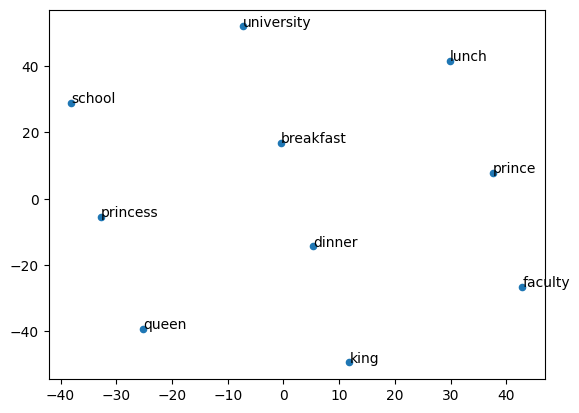

In [28]:
vocab = ['university', 'school', 'faculty',
		 'king', 'prince', 'queen', 'princess',
		 'breakfast', 'dinner', 'lunch']

embedding_matrix = create_embedding_matrix(model, vocab)

# Si bien no es estrictamente necesario, es habitual usar antes PCA para reducir la dimensionalidad a unos 50 componentes principales
# para que tSNE sea más eficiente (tSNE es mucho más lento que PCA con muchas dimensiones)
from sklearn.decomposition import PCA
pca = PCA(n_components=min(50, embedding_matrix.shape[0], embedding_matrix.shape[1])) # reducimos a 50 componentes
X_50 = pca.fit_transform(embedding_matrix) # aplicamos PCA a la matriz de embeddings

# Ahora podemos usar tSNE para reducir a 2 dimensiones
from sklearn.manifold import TSNE
n_samples = X_50.shape[0]
perplexity = min(30, n_samples - 1)  # debe ser < n_samples
model_tsne = TSNE(n_components=2, random_state=0, perplexity=perplexity)
Y = model_tsne.fit_transform(X_50)

# Y finalmente, mostramos las palabras en un scatter plot
import matplotlib.pyplot as plt
plt.scatter(Y[:, 0], Y[:, 1], 20)

# Añadimos las etiquetas de las palabras
for label, x, y in zip(vocab, Y[:, 0], Y[:, 1]):
	plt.annotate(label, xy=(x, y), xytext=(0, 0), textcoords='offset points', size=10)

plt.show()

Y si quisiéramos proyectar en 3d

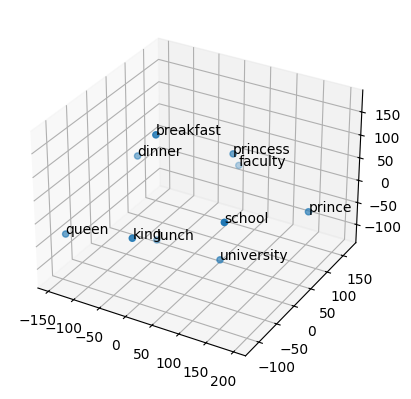

In [29]:
from mpl_toolkits.mplot3d import Axes3D

# Reducimos a 3 dimensiones con t-SNE
model_tsne_3d = TSNE(n_components=3, random_state=0)
n_samples_3d = X_50.shape[0]
perplexity_3d = max(1, min(30, n_samples_3d - 1))  # t-SNE exige perplexity < n_samples
model_tsne_3d = TSNE(n_components=3, random_state=0, perplexity=perplexity_3d)
Y_3d = model_tsne_3d.fit_transform(X_50)

# Mostramos las palabras en un scatter plot 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(Y_3d[:, 0], Y_3d[:, 1], Y_3d[:, 2], s=20)

# Añadimos las etiquetas de las palabras
for label, x, y, z in zip(vocab, Y_3d[:, 0], Y_3d[:, 1], Y_3d[:, 2]):
    ax.text(x, y, z, label)

plt.show()

# Más sobre modelos preentrenados

Gensim proporciona varios modelos preentrenados en su repositorio [Gensim-data](https://github.com/piskvorky/gensim-data),
que se pueden cargar fácilmente con `gensim.downloader.load()`.

Para ver todos los modelos disponibles en gensim, podemos usar:

In [2]:
import gensim.downloader

list(gensim.downloader.info()['models'].keys())

['fasttext-wiki-news-subwords-300',
 'conceptnet-numberbatch-17-06-300',
 'word2vec-ruscorpora-300',
 'word2vec-google-news-300',
 'glove-wiki-gigaword-50',
 'glove-wiki-gigaword-100',
 'glove-wiki-gigaword-200',
 'glove-wiki-gigaword-300',
 'glove-twitter-25',
 'glove-twitter-50',
 'glove-twitter-100',
 'glove-twitter-200',
 '__testing_word2vec-matrix-synopsis']

Para descargar un modelo preentrenado, basta con usar su nombre en la función load de gensim.downloader.

Probemos con el modelo "glove-twitter-25", que tiene vectores de 25 dimensiones entrenados con tweets

In [3]:
glove_vectors = gensim.downloader.load('glove-twitter-25')
glove_vectors.most_similar('twitter')

[==================================================] 100.0% 104.8/104.8MB downloaded


[('facebook', 0.948005199432373),
 ('tweet', 0.9403423070907593),
 ('fb', 0.9342358708381653),
 ('instagram', 0.9104824066162109),
 ('chat', 0.8964964747428894),
 ('hashtag', 0.8885937333106995),
 ('tweets', 0.8878158330917358),
 ('tl', 0.8778461217880249),
 ('link', 0.8778210878372192),
 ('internet', 0.8753897547721863)]

In [4]:
model = glove_vectors

Para cargar el modelo preentrenado de Google News (300 dimensiones, 3 millones de palabras):

In [5]:
google_news = gensim.downloader.load('word2vec-google-news-300')
google_news.most_similar(positive=['twitter'])

[==================================================] 100.0% 1662.8/1662.8MB downloaded


[('Twitter', 0.8908904194831848),
 ('Twitter.com', 0.7536780834197998),
 ('tweet', 0.7431626319885254),
 ('tweeting', 0.7161932587623596),
 ('tweeted', 0.7137226462364197),
 ('facebook', 0.6988551616668701),
 ('tweets', 0.6974530816078186),
 ('Tweeted', 0.6950210928916931),
 ('Tweet', 0.6875007152557373),
 ('Tweeting', 0.6845167279243469)]

Prueba las similitudes que hicimos arriba, pero esta vez con el modelo Glove y con el modelo Google News.

¿Qué diferencias observas? ¿A qué crees que se deben?